## Predicción del Costo del Seguro Médico

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')
import urllib.request
import os

# Configurar el tamaño de las gráficas lo conseguido como una buena practica para falicitar la visualización de los datos
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

# Descargar y cargar el dataset

In [2]:

url = 'https://breathecode.herokuapp.com/asset/internal-link?id=929&path=medical_insurance_cost.csv'
archivo = '../data/raw/medical_insurance_cost.csv'

# Crear la carpeta si no existe
os.makedirs(os.path.dirname(archivo), exist_ok=True)

try:
    urllib.request.urlretrieve(url, archivo)
    print('Archivo descargado correctamente')
except Exception as e:
    print(f'Error al descargar: {e}')

# Cargar los datos
df = pd.read_csv(archivo)
print('Dataset cargado correctamente')
print(f'Dimensiones: {df.shape}')

Archivo descargado correctamente
Dataset cargado correctamente
Dimensiones: (1338, 7)


## Análisis Exploratorio 

In [4]:
# Ver las primeras filas
print('Primeras 5 filas del dataset:')
print(df.head())
print('\n')

# Ver la información del dataset
print('Información del dataset:')
print(df.info())
print('\n')


Primeras 5 filas del dataset:
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


Información del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB
None




In [5]:
# Ver estadísticas básicas
print('Estadísticas descriptivas:')
print(df.describe())

Estadísticas descriptivas:
               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      64.000000    53.130000     5.000000  63770.428010


Nota: en charges se nota que puede ser que el 63770 sea algo extraordinario, lo que no sé es si eliminarlo.

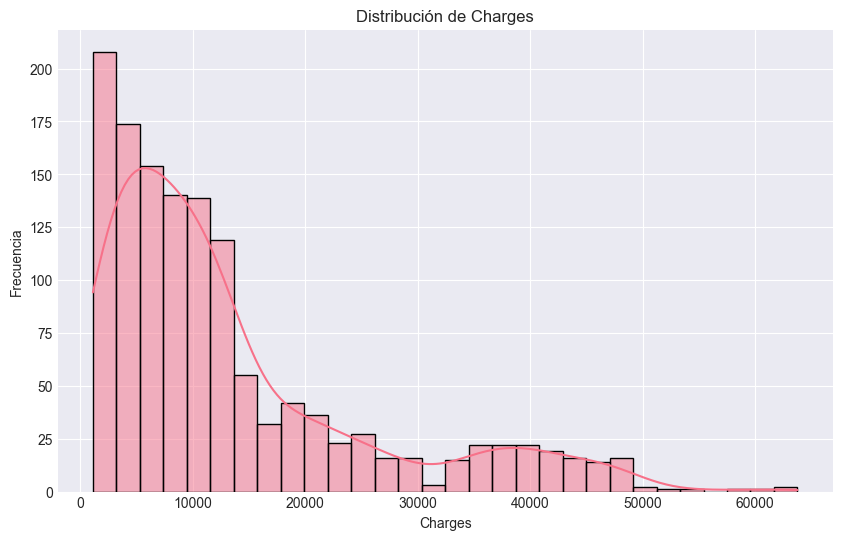

In [6]:
# El 50% y el mean de charges tienen mucha diferencia debo evaluar si hay outliers en esta columna, lo que puede afectar el rendimiento del modelo.
# Aislar la comlumna de charges para evaluar su distribución
charges = df['charges']
plt.figure(figsize=(10, 6))
sns.histplot(charges, bins=30, kde=True)
plt.title('Distribución de Charges')
plt.xlabel('Charges')
plt.ylabel('Frecuencia')
plt.show()


In [9]:
# Calcular porcentaje de outliers (método del IQR ayudado con la IA)
Q1 = charges.quantile(0.25)
Q3 = charges.quantile(0.75) 
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = charges[(charges < lower_bound) | (charges > upper_bound)]
percent_outliers = (len(outliers) / len(charges)) * 100
print(f'Porcentaje de outliers en charges: {percent_outliers:.2f}%')


Porcentaje de outliers en charges: 10.39%


Nota, vamos a probar porque modificar 10% de la muestra me parece demasiado.

In [11]:
# Verificar valores faltantes
print('Valores faltantes por columna:')
print(df.isnull().sum())
print('\n')


Valores faltantes por columna:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64




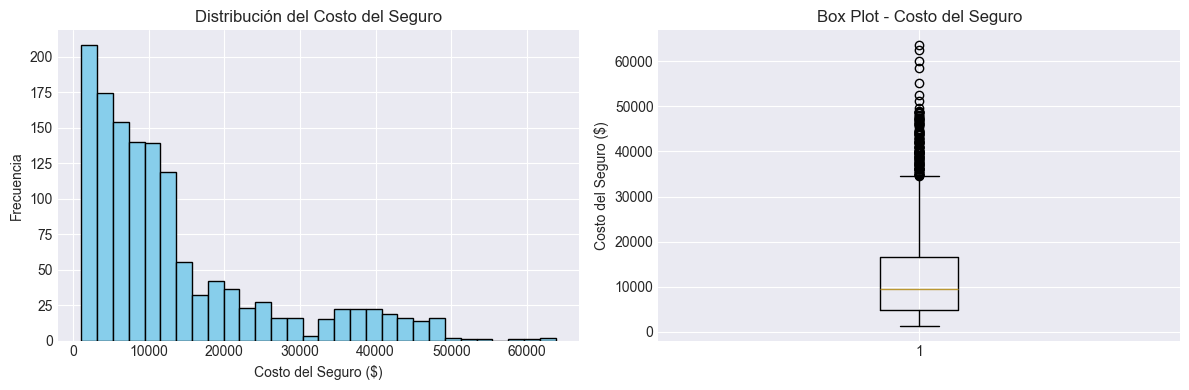

In [12]:
# Visualizar la distribución de la variable objetivo (charges)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma
axes[0].hist(df['charges'], bins=30, color='skyblue', edgecolor='black')
axes[0].set_xlabel('Costo del Seguro ($)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución del Costo del Seguro')

# Box plot
axes[1].boxplot(df['charges'])
axes[1].set_ylabel('Costo del Seguro ($)')
axes[1].set_title('Box Plot - Costo del Seguro')

plt.tight_layout()
plt.show()

In [13]:
# Analizar las variables categóricas
print('Variables categóricas y sus valores únicos:')
print('\nSexo:')
print(df['sex'].value_counts())
print('\nFumador:')
print(df['smoker'].value_counts())
print('\nRegión:')
print(df['region'].value_counts())

Variables categóricas y sus valores únicos:

Sexo:
sex
male      676
female    662
Name: count, dtype: int64

Fumador:
smoker
no     1064
yes     274
Name: count, dtype: int64

Región:
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


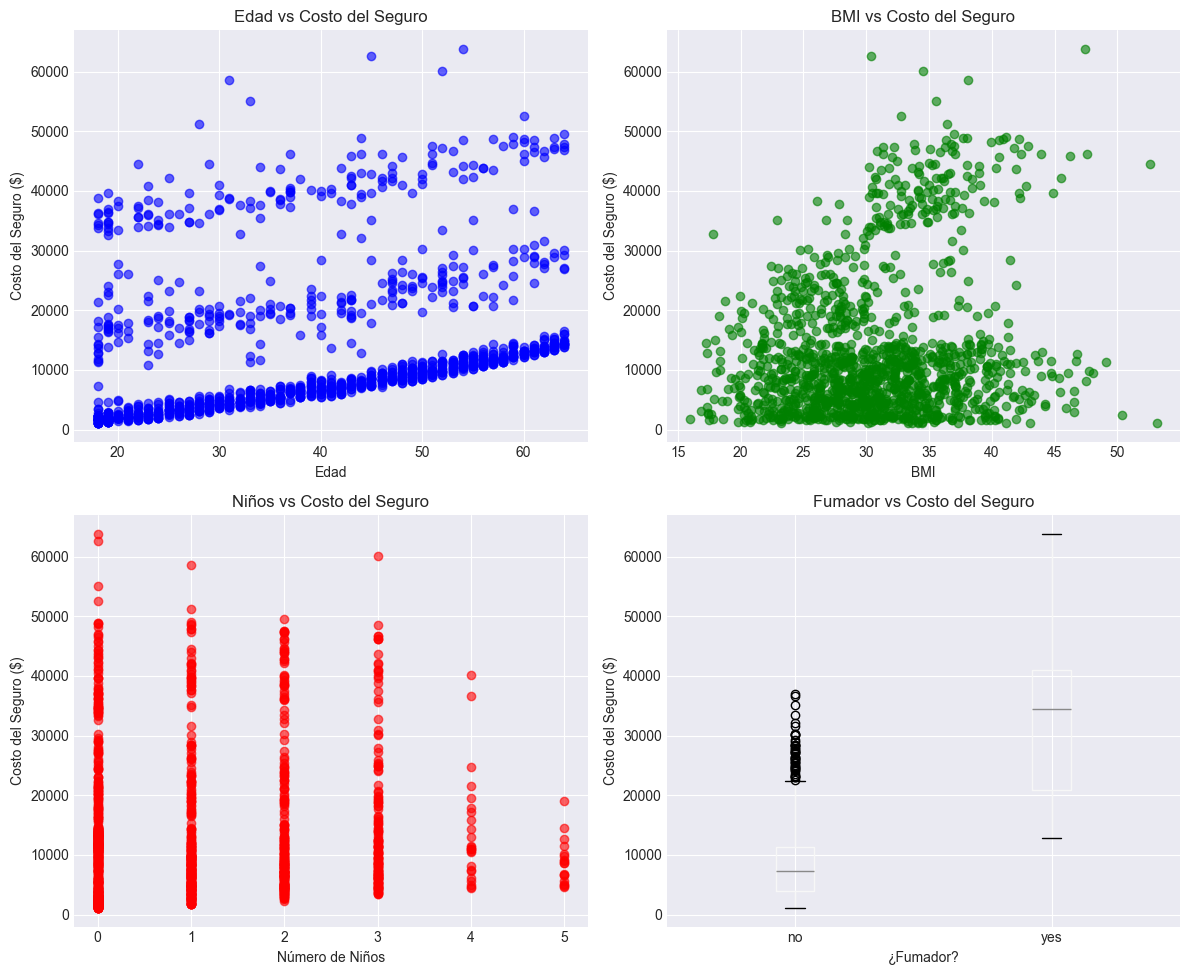

In [14]:
# Visualizar la relación entre variables numéricas y el costo
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Age vs Charges
axes[0, 0].scatter(df['age'], df['charges'], alpha=0.6, color='blue')
axes[0, 0].set_xlabel('Edad')
axes[0, 0].set_ylabel('Costo del Seguro ($)')
axes[0, 0].set_title('Edad vs Costo del Seguro')

# BMI vs Charges
axes[0, 1].scatter(df['bmi'], df['charges'], alpha=0.6, color='green')
axes[0, 1].set_xlabel('BMI')
axes[0, 1].set_ylabel('Costo del Seguro ($)')
axes[0, 1].set_title('BMI vs Costo del Seguro')

# Children vs Charges
axes[1, 0].scatter(df['children'], df['charges'], alpha=0.6, color='red')
axes[1, 0].set_xlabel('Número de Niños')
axes[1, 0].set_ylabel('Costo del Seguro ($)')
axes[1, 0].set_title('Niños vs Costo del Seguro')

# Smoker vs Charges (box plot)
df.boxplot(column='charges', by='smoker', ax=axes[1, 1])
axes[1, 1].set_xlabel('¿Fumador?')
axes[1, 1].set_ylabel('Costo del Seguro ($)')
axes[1, 1].set_title('Fumador vs Costo del Seguro')

plt.suptitle('')
plt.tight_layout()
plt.show()

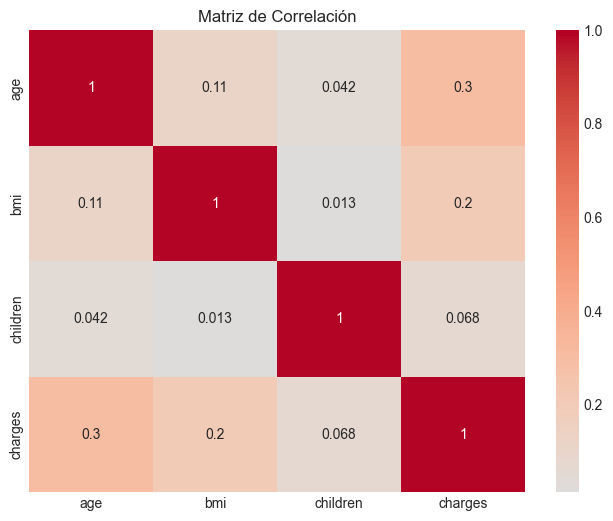

In [17]:
# Visualizar la matriz de correlación
correlacion = df[['age', 'bmi', 'children', 'charges']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlacion, annot=True, cmap='coolwarm', center=0)
plt.title('Matriz de Correlación')
plt.show()

No entiendo muy bien el porqué pero la correlación es que cuando más hijos tienes más económico es el seguro y la correlación con la edad no es tan alta como debería. Según yo y mi lógica claro.


## Preparación de Datos para el Modelo

In [18]:
# Crear una copia del dataframe para trabajar
df_modelo = df.copy()

# Codificar las variables categóricas
df_modelo['sex'] = df_modelo['sex'].map({'male': 1, 'female': 0})

df_modelo['smoker'] = df_modelo['smoker'].map({'yes': 1, 'no': 0})

# Para 'region' necesita Label Encoding
le = LabelEncoder()
df_modelo['region'] = le.fit_transform(df_modelo['region'])

print('Datos después de codificación:')
print(df_modelo.head())


Datos después de codificación:
   age  sex     bmi  children  smoker  region      charges
0   19    0  27.900         0       1       3  16884.92400
1   18    1  33.770         1       0       2   1725.55230
2   28    1  33.000         3       0       2   4449.46200
3   33    1  22.705         0       0       1  21984.47061
4   32    1  28.880         0       0       1   3866.85520


In [ ]:
# Separar las características
X = df_modelo.drop('charges', axis=1)
y = df_modelo['charges']

# Dividir los datos en conjunto de entrenamiento y prueba (aunque son pocos datos para no perder la costumbre de hacerlo)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Tamaño del conjunto de entrenamiento: {X_train.shape[0]}')
print(f'Tamaño del conjunto de prueba: {X_test.shape[0]}')
print(f'Proporción: {X_train.shape[0] / len(X) * 100:.1f}% entrenamiento, {X_test.shape[0] / len(X) * 100:.1f}% prueba')

Tamaño del conjunto de entrenamiento: 1070
Tamaño del conjunto de prueba: 268
Proporción: 80.0% entrenamiento, 20.0% prueba


## Construir el Modelo de Regresión Lineal

In [21]:
# Crear y entrenar el modelo de regresión lineal
modelo = LinearRegression()
modelo.fit(X_train, y_train)

print('Modelo entrenado correctamente')
print('\nCoeficientes del modelo:')
for nombre, coef in zip(X.columns, modelo.coef_):
    print(f'{nombre}: {coef:.2f}')
print(f'Intercepción: {modelo.intercept_:.2f}')

Modelo entrenado correctamente

Coeficientes del modelo:
age: 257.06
sex: -18.79
bmi: 335.78
children: 425.09
smoker: 23647.82
region: -271.28
Intercepción: -11946.61


In [22]:
# Realizar predicciones en el conjunto de prueba
y_pred = modelo.predict(X_test)

# Calcular métricas de rendimiento
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print('Métricas de rendimiento en el conjunto de prueba:')
print(f'MSE (Error Cuadrado Medio): {mse:.2f}')
print(f'RMSE (Raíz del Error Cuadrado Medio): {rmse:.2f}')
print(f'R² Score: {r2:.4f}')

Métricas de rendimiento en el conjunto de prueba:
MSE (Error Cuadrado Medio): 33635210.43
RMSE (Raíz del Error Cuadrado Medio): 5799.59
R² Score: 0.7833


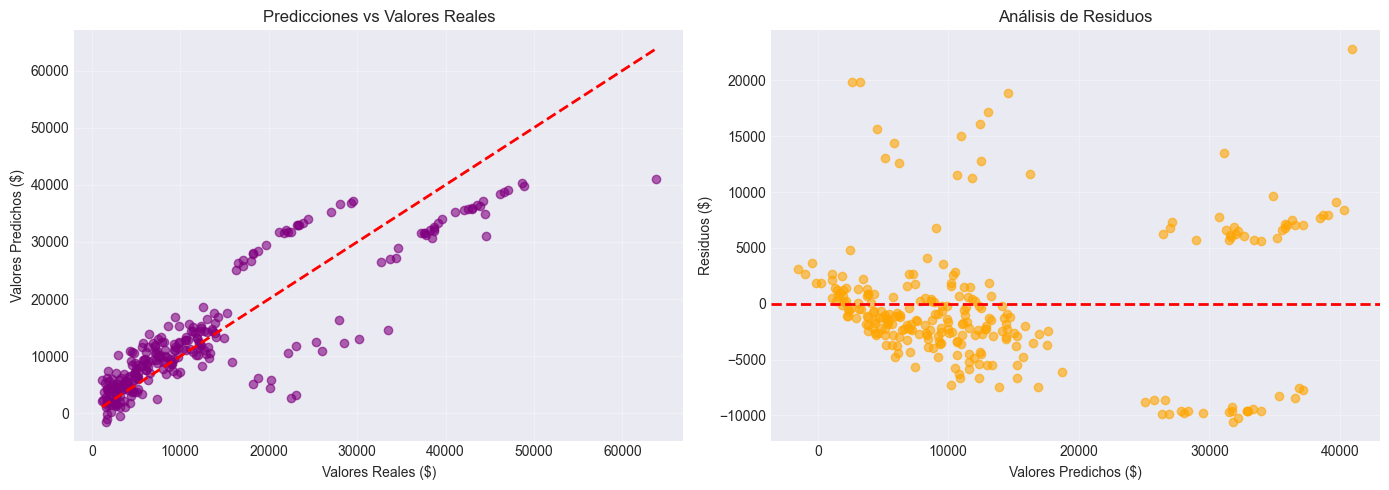

In [23]:
# Visualizar predicciones vs valores reales
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot: Valores reales vs Predichos
axes[0].scatter(y_test, y_pred, alpha=0.6, color='purple')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Valores Reales ($)')
axes[0].set_ylabel('Valores Predichos ($)')
axes[0].set_title('Predicciones vs Valores Reales')
axes[0].grid(True, alpha=0.3)

# Residuos
residuos = y_test - y_pred
axes[1].scatter(y_pred, residuos, alpha=0.6, color='orange')
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Valores Predichos ($)')
axes[1].set_ylabel('Residuos ($)')
axes[1].set_title('Análisis de Residuos')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Optimización del Modelo

Aun que estos modelos no se optimizan como regresión Lógica, esta el tema de los outliers, por eso pido ayuda a la IA para ver si lo podemos mejorar.

In [24]:
# Evaluar el modelo también en el conjunto de entrenamiento
y_train_pred = modelo.predict(X_train)

mse_train = mean_squared_error(y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)
r2_train = r2_score(y_train, y_train_pred)

print('Comparación de métricas (Entrenamiento vs Prueba):')
print(f'\n{"Métrica":<20} {"Entrenamiento":<20} {"Prueba":<20}')
print('-' * 60)
print(f'{"RMSE":<20} {rmse_train:<20.2f} {rmse:<20.2f}')
print(f'{"R² Score":<20} {r2_train:<20.4f} {r2:<20.4f}')

# Verificar si hay sobreajuste
if r2_train - r2 > 0.05:
    print('\n⚠️ Posible sobreajuste detectado (diferencia > 0.05)')
else:
    print('\n✓ El modelo está balanceado (sin sobreajuste evidente)')

Comparación de métricas (Entrenamiento vs Prueba):

Métrica              Entrenamiento        Prueba              
------------------------------------------------------------
RMSE                 6105.79              5799.59             
R² Score             0.7417               0.7833              

✓ El modelo está balanceado (sin sobreajuste evidente)


In [25]:
# Análisis de residuos para detección de outliers
print('Análisis de residuos para detección de outliers:')
residuos_train = y_train - y_train_pred
desv_std = np.std(residuos_train)

# Contar outliers (residuos > 2 desviaciones estándar)
outliers = np.abs(residuos_train) > 2 * desv_std
num_outliers = outliers.sum()
print(f'Número de outliers detectados: {num_outliers}')
print(f'Porcentaje: {num_outliers / len(y_train) * 100:.2f}%')

Análisis de residuos para detección de outliers:
Número de outliers detectados: 54
Porcentaje: 5.05%


In [26]:
# Reentrenar el modelo sin outliers si hay demasiados
if num_outliers > 0:
    # Crear índices sin outliers
    X_train_limpio = X_train[~outliers]
    y_train_limpio = y_train[~outliers]

    # Crear y entrenar un nuevo modelo
    modelo_mejorado = LinearRegression()
    modelo_mejorado.fit(X_train_limpio, y_train_limpio)

    # Evaluar el modelo mejorado
    y_pred_mejorado = modelo_mejorado.predict(X_test)
    rmse_mejorado = np.sqrt(mean_squared_error(y_test, y_pred_mejorado))
    r2_mejorado = r2_score(y_test, y_pred_mejorado)

    print('\nComparación del modelo original vs mejorado:')
    print(f'{"Métrica":<20} {"Original":<20} {"Mejorado":<20}')
    print('-' * 60)
    print(f'{"RMSE":<20} {rmse:<20.2f} {rmse_mejorado:<20.2f}')
    print(f'{"R² Score":<20} {r2:<20.4f} {r2_mejorado:<20.4f}')

    # Usar el modelo mejorado si es significativamente mejor
    if rmse_mejorado < rmse:
        print('\n✓ El modelo mejorado es mejor, usaremos este')
        modelo = modelo_mejorado
        y_pred = y_pred_mejorado
        rmse = rmse_mejorado
        r2 = r2_mejorado
    else:
        print('\n✓ El modelo original sigue siendo mejor')


Comparación del modelo original vs mejorado:
Métrica              Original             Mejorado            
------------------------------------------------------------
RMSE                 5799.59              5865.91             
R² Score             0.7833               0.7784              

✓ El modelo original sigue siendo mejor


In [27]:
# Resumen final del modelo
print('=' * 60)
print('RESUMEN FINAL DEL MODELO')
print('=' * 60)
print(f'\nModelo: Regresión Lineal')
print(f'Variables utilizadas: {list(X.columns)}')
print(f'\nDatos de entrenamiento: {X_train.shape[0]} muestras')
print(f'Datos de prueba: {X_test.shape[0]} muestras')
print(f'\nRMSE en prueba: ${rmse:.2f}')
print(f'R² Score en prueba: {r2:.4f}')
print(f'\nInterpretación:')
print(f'- El modelo explica el {r2*100:.2f}% de la varianza en los costos')
print(f'- El error promedio en las predicciones es de ${rmse:.2f}')
print('=' * 60)

RESUMEN FINAL DEL MODELO

Modelo: Regresión Lineal
Variables utilizadas: ['age', 'sex', 'bmi', 'children', 'smoker', 'region']

Datos de entrenamiento: 1070 muestras
Datos de prueba: 268 muestras

RMSE en prueba: $5799.59
R² Score en prueba: 0.7833

Interpretación:
- El modelo explica el 78.33% de la varianza en los costos
- El error promedio en las predicciones es de $5799.59


Nota: aunque la IA a gestionado los outliers desde las muestras separadas, en producción real yo hubiece directamente modificado los outliers, porque a mi me daba que eran cerca del 10% y luego aparece cerca del 5%, quizás se puede mejorar la métrica si modificamos al comienzo. Pero eso será cuando tenga tiempo.